In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import linearsolve as ls

T_bar is 1.1170996977881216


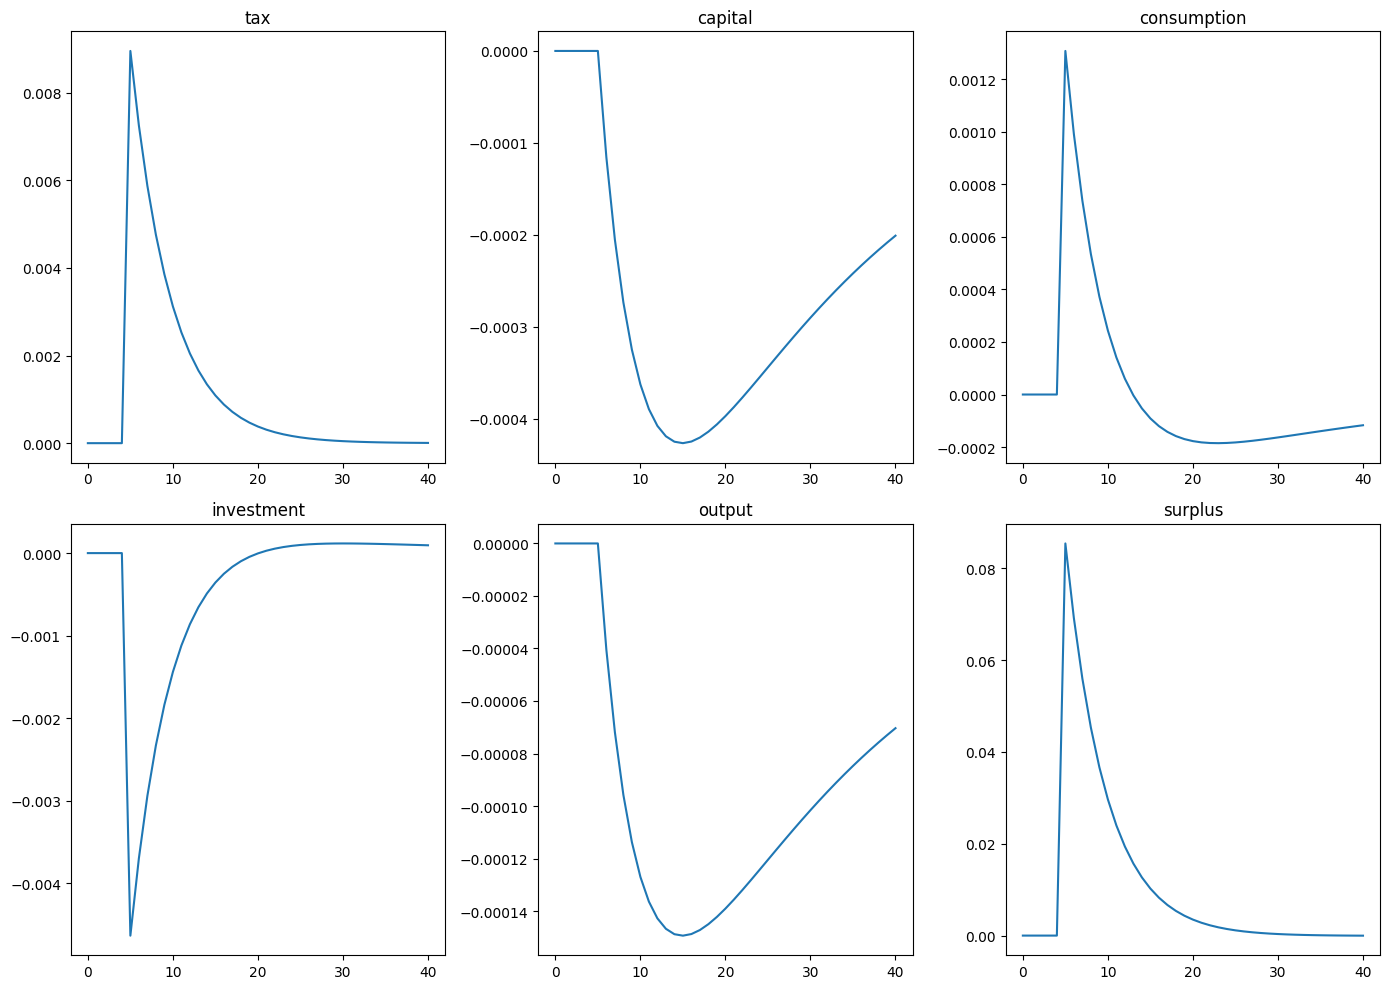

In [3]:
#download federal government current tax receipts and gdp from FRED
df_tax = pd.read_csv('https://fred.stlouisfed.org/graph/fredgraph.csv?id=W006RC1Q027SBEA',index_col=0,parse_dates=True)
df_gdp = pd.read_csv('https://fred.stlouisfed.org/graph/fredgraph.csv?id=GDP',index_col=0,parse_dates=True)

#making things easier to parse
df_tax.columns = ['tax_receipts']
df_gdp.columns = ['gdp']
df = df_tax.join(df_gdp, how='inner')

#compute tax to gdp ratio and average ratio
df['tax_gdp_ratio'] = df['tax_receipts'] / df['gdp']
avg_ratio = df['tax_gdp_ratio'].mean()
T_bar = 1 + avg_ratio
print(f"T_bar is {T_bar}")

#creating the parameters, endo and costates
parameters = pd.Series(dtype=float)
parameters['beta'] = 0.9900
parameters['alpha'] = 0.3500
parameters['delta'] = 0.0250
parameters['T_bar'] = T_bar
parameters['rho_t'] = 0.8100
parameters['sigma_t'] = 0.0390
parameters['rho_a'] = 0.7500
parameters['sigma_a'] = 0.0060
exo_states = ('a','t')
endo_states = ('k')
costates = ('c','i','y','s')

#defining function equations for linearsolve later
def equations(variables_forward,variables_current,parameters):
    # Parameters
    p = parameters

    # Current variables
    cur = variables_current

    # Forward variables
    fwd = variables_forward

    #euler equation
    euler_equation = p.beta * ((2 - fwd.t) * p.alpha * fwd.a * fwd.k**(p.alpha - 1) + 1 - p.delta) / fwd.c - 1/cur.c

    #tfp evolution
    tfp_evolution = np.log(fwd.a) - p.rho_a * np.log(cur.a)

    #tax evolution
    tax_evolution = np.log(fwd.t) - (np.log(p.T_bar)*(1 - p.rho_t) + np.log(cur.t)*p.rho_t)

    #government budget constraint
    gov_budget_constraint = cur.s - (cur.t - 1) * cur.y

    #capital evolution
    capital_evolution = cur.i + (1 - p.delta) * cur.k - fwd.k

    #production function
    production_function = cur.a * cur.k**p.alpha - cur.y

    #market clearing
    market_clearing = cur.c + cur.i - cur.y

    return np.array([
        euler_equation,
        tfp_evolution,
        tax_evolution,
        gov_budget_constraint,
        capital_evolution,
        production_function,
        market_clearing
    ])

#now lets compute the steady state
rbc_model = ls.model(equations=equations, exo_states=exo_states,costates=costates,endo_states=endo_states,parameters=parameters)
rbc_model.compute_ss()
#unfortunately muhammad has hit a roadblock right here - gpt and gemini has failed him and muhammad mind has exploded trying to fix this for the last 40 min.
#update: matthew hirokawa is the goat

#now for the impulse shocks
rbc_model.approximate_and_solve()
rbc_model.impulse(T=41,t0=5,shocks=[0,0.01])

#time to graph!
fig = plt.figure(figsize=(14,10))
ax2 = fig.add_subplot(2,3,1)
ax3 = fig.add_subplot(2,3,2)
ax4 = fig.add_subplot(2,3,3)
ax5 = fig.add_subplot(2,3,4)
ax6 = fig.add_subplot(2,3,5)
ax7 = fig.add_subplot(2,3,6)


(rbc_model.irs['e_t']['t']).plot(ax=ax2, title='tax')
(rbc_model.irs['e_t']['k']).plot(ax=ax3, title='capital')
(rbc_model.irs['e_t']['c']).plot(ax=ax4, title='consumption')
(rbc_model.irs['e_t']['i']).plot(ax=ax5, title='investment')
(rbc_model.irs['e_t']['y']).plot(ax=ax6, title='output')
(rbc_model.irs['e_t']['s']).plot(ax=ax7, title='surplus')
fig.tight_layout()

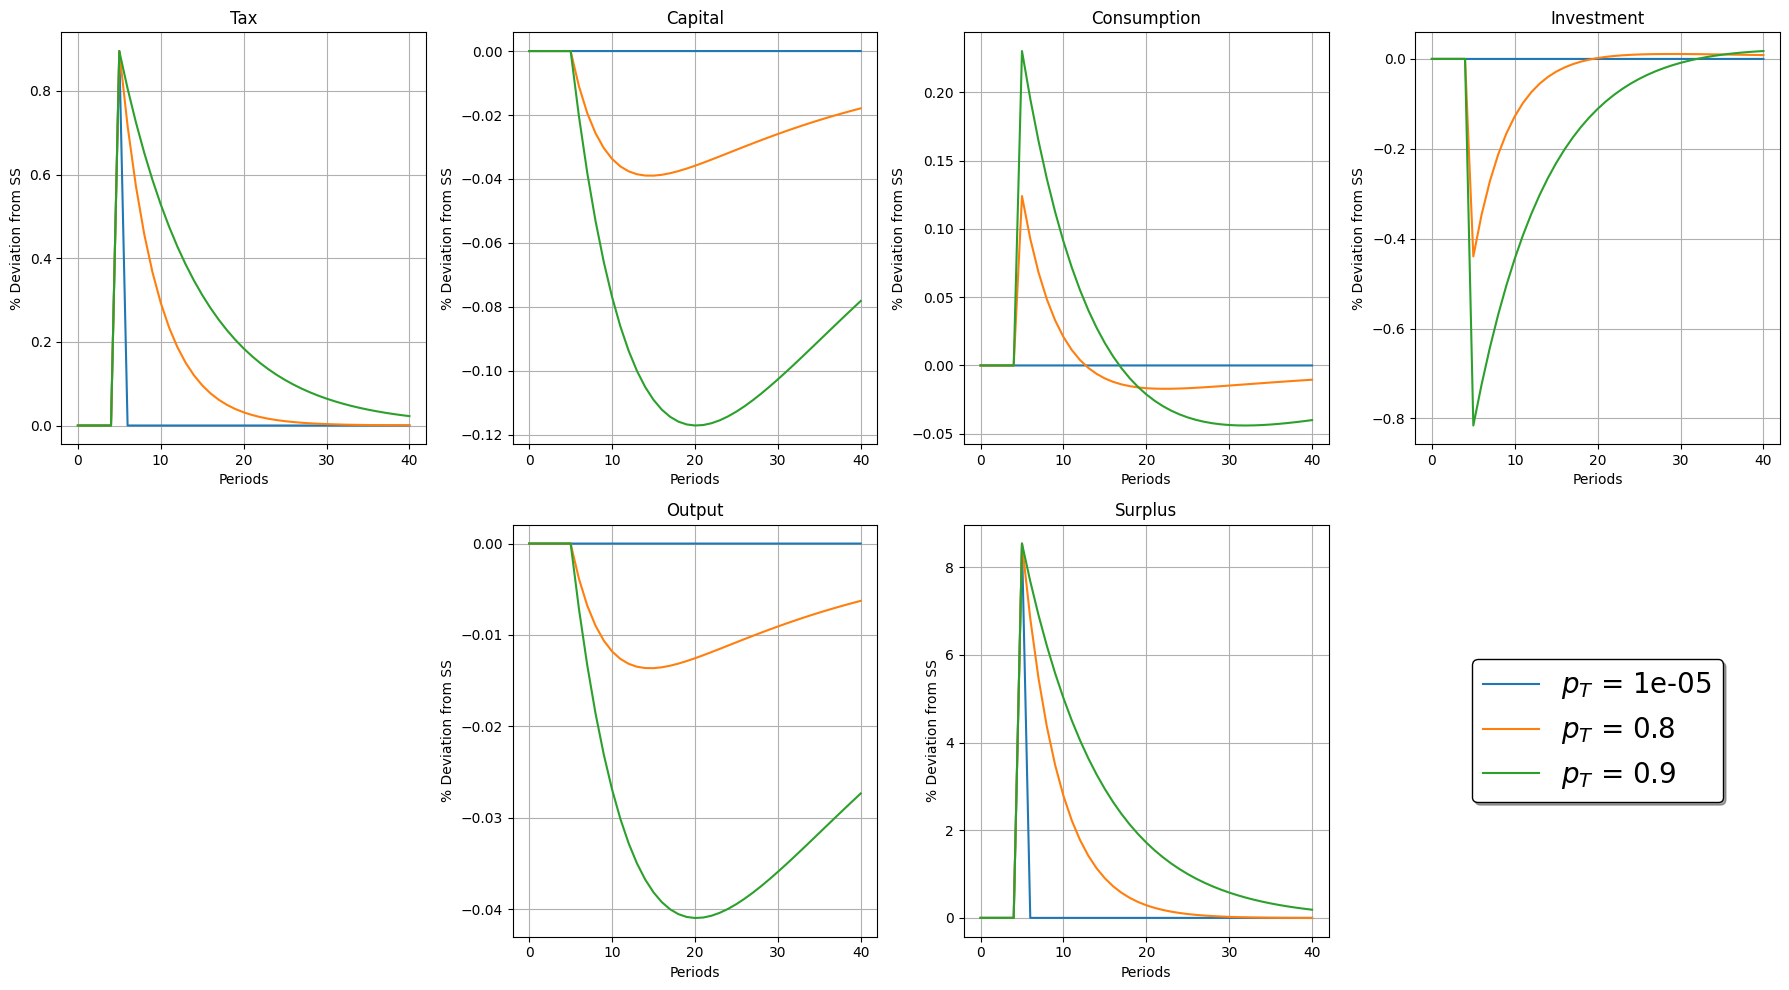

In [4]:
#computing impulse responses for rho_t = 0.00001,0.8 and 0.99 -> creating a for loop to graph and calculate for the different rho_t's
rho_values = [0.00001, 0.8, 0.9]
irfs = {}

for rho in rho_values:
    parameters['rho_t'] = rho

    model = ls.model(equations=equations,exo_states=exo_states,
                    endo_states=endo_states,costates=costates,
                    parameters=parameters)
    model.compute_ss()
    model.approximate_and_solve()
    model.impulse(T=41,t0=5,shocks=[0,0.01])

    irfs[rho] = model.irs['e_t']


fig = plt.figure(figsize=(18,10))
ax2 = fig.add_subplot(2,4,1)
ax3 = fig.add_subplot(2,4,2)
ax4 = fig.add_subplot(2,4,3)
ax5 = fig.add_subplot(2,4,4)
ax6 = fig.add_subplot(2,4,6)
ax7 = fig.add_subplot(2,4,7)
ax8 = fig.add_subplot(2,4,8)

variables = ['t','k','c','i','y','s']
axes = [ax2,ax3,ax4,ax5,ax6,ax7]
titles = ['Tax','Capital','Consumption','Investment','Output','Surplus']

for ax, var, title in zip(axes, variables, titles):
    for rho in rho_values:
        (irfs[rho][var]*100).plot(ax=ax,label=f'$p_T$ = {rho}')
    ax.set_title(title)
    ax.set_xlabel('Periods')
    ax.set_ylabel('% Deviation from SS')
    ax.grid()

#for the legend!
ax8.axis('off')
handles, labels = ax2.get_legend_handles_labels()
ax8.legend(handles, labels, loc='center', frameon=True, fontsize=20,fancybox=True,shadow=True,edgecolor='black',facecolor='white' )

fig.tight_layout()